# CNN con PyTorch — Classificazione su CIFAR-10

In questo notebook addestriamo una **Rete Neurale Convoluzionale (CNN)** per classificare immagini a colori del dataset **CIFAR-10**.

### Le 10 classi di CIFAR-10
`airplane`, `automobile`, `bird`, `cat`, `deer`, `dog`, `frog`, `horse`, `ship`, `truck`

## 1. Import e Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Usa GPU se disponibile
if torch.cuda.is_available():
    device = torch.device('cuda')   # NVIDIA (Linux/Windows)
elif torch.backends.mps.is_available():
    device = torch.device('mps')    # Apple Silicon M1/M2/M3
else:
    device = torch.device('cpu')    # fallback
print(f"Dispositivo: {device}")

# Nomi delle classi CIFAR-10
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

Dispositivo: mps


## 2. Caricamento del Dataset CIFAR-10

Le immagini CIFAR-10 sono **32×32 pixel RGB**. Applichiamo:
- **Data augmentation** sul training set (flip orizzontale casuale + crop) per migliorare la generalizzazione
- **Normalizzazione** con la media e std del dataset CIFAR-10

In [3]:
# Trasformazioni per il training (con data augmentation)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # flip casuale
    transforms.RandomCrop(32, padding=4),       # crop con padding
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),          # media per canale R, G, B
        std=(0.2023, 0.1994, 0.2010)            # std per canale R, G, B
    )
])

# Trasformazioni per il test (solo normalizzazione, no augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

# Scarica e carica i dataset
train_dataset = datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
test_dataset  = datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Batch shape   : {next(iter(train_loader))[0].shape}")

100%|██████████| 170M/170M [00:19<00:00, 8.56MB/s] 
/Users/gcoucourde/miniconda3/envs/pycourse/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples : 50000
Test  samples : 10000
Batch shape   : torch.Size([128, 3, 32, 32])


## 3. Visualizzazione di qualche immagine

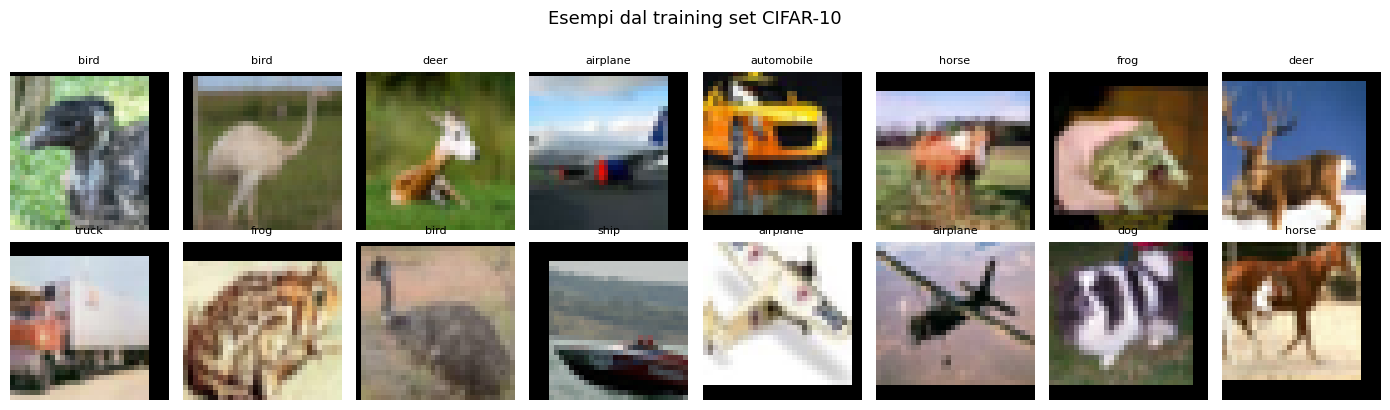

In [4]:
def denormalize(img_tensor):
    """Riporta il tensore normalizzato a valori [0,1] per la visualizzazione."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Esempi dal training set CIFAR-10', fontsize=13, y=1.02)

for i, ax in enumerate(axes.flat):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Definizione del Modello CNN

Usiamo un'architettura leggermente più profonda rispetto alla versione MNIST, perché CIFAR-10 è più complesso:

- **3 blocchi convoluzionali** (invece di 2) per estrarre feature più ricche
- **Batch Normalization** dopo ogni conv per stabilizzare il training
- Input con **3 canali** (RGB) invece di 1

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Blocco 1: 3 → 32 canali, 32×32 → 16×16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # input: 3 canali RGB!
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # 32×32 → 16×16
        )

        # Blocco 2: 32 → 64 canali, 16×16 → 8×8
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # 16×16 → 8×8
        )

        # Blocco 3: 64 → 128 canali, 8×8 → 4×4
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # 8×8 → 4×4
        )

        # Classificatore fully-connected
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # 128 × 4 × 4 = 2048
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)                          # 10 classi
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


model = CNN().to(device)

# Conta i parametri
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParametri totali: {n_params:,}")

CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=2

## 5. Training

Usiamo:
- **Adam** come ottimizzatore
- **CrossEntropyLoss** come funzione di loss
- **Learning rate scheduler** che riduce il lr se la loss smette di migliorare

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            total_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


NUM_EPOCHS = 15
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc = evaluate(model, test_loader)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  "
          f"train_loss: {tr_loss:.4f}  train_acc: {tr_acc:.4f}  "
          f"val_loss: {vl_loss:.4f}  val_acc: {vl_acc:.4f}")

Epoch  1/15  train_loss: 1.6143  train_acc: 0.4020  val_loss: 1.2500  val_acc: 0.5327
Epoch  2/15  train_loss: 1.2978  train_acc: 0.5287  val_loss: 1.0658  val_acc: 0.6085
Epoch  3/15  train_loss: 1.1536  train_acc: 0.5879  val_loss: 0.9457  val_acc: 0.6630
Epoch  4/15  train_loss: 1.0686  train_acc: 0.6213  val_loss: 0.8629  val_acc: 0.6914
Epoch  5/15  train_loss: 1.0126  train_acc: 0.6418  val_loss: 0.8286  val_acc: 0.7100
Epoch  6/15  train_loss: 0.9561  train_acc: 0.6652  val_loss: 0.8025  val_acc: 0.7145
Epoch  7/15  train_loss: 0.9178  train_acc: 0.6802  val_loss: 0.7808  val_acc: 0.7336
Epoch  8/15  train_loss: 0.8863  train_acc: 0.6896  val_loss: 0.7493  val_acc: 0.7317
Epoch  9/15  train_loss: 0.8525  train_acc: 0.7063  val_loss: 0.7244  val_acc: 0.7424
Epoch 10/15  train_loss: 0.8300  train_acc: 0.7136  val_loss: 0.7160  val_acc: 0.7486
Epoch 11/15  train_loss: 0.8102  train_acc: 0.7197  val_loss: 0.6916  val_acc: 0.7584
Epoch 12/15  train_loss: 0.7914  train_acc: 0.7280  va

## 6. Curve di Training

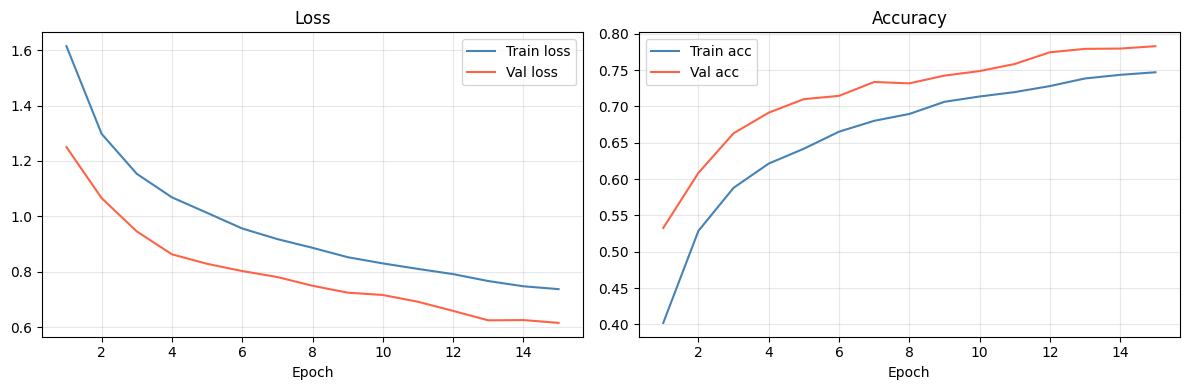


Best val accuracy: 0.7829 (78.29%)


In [7]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(epochs, history['train_loss'], label='Train loss', color='steelblue')
ax1.plot(epochs, history['val_loss'],   label='Val loss',   color='tomato')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs, history['train_acc'], label='Train acc', color='steelblue')
ax2.plot(epochs, history['val_acc'],   label='Val acc',   color='tomato')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest val accuracy: {max(history['val_acc']):.4f} ({max(history['val_acc'])*100:.2f}%)")

## 7. Predizioni su Immagini di Test

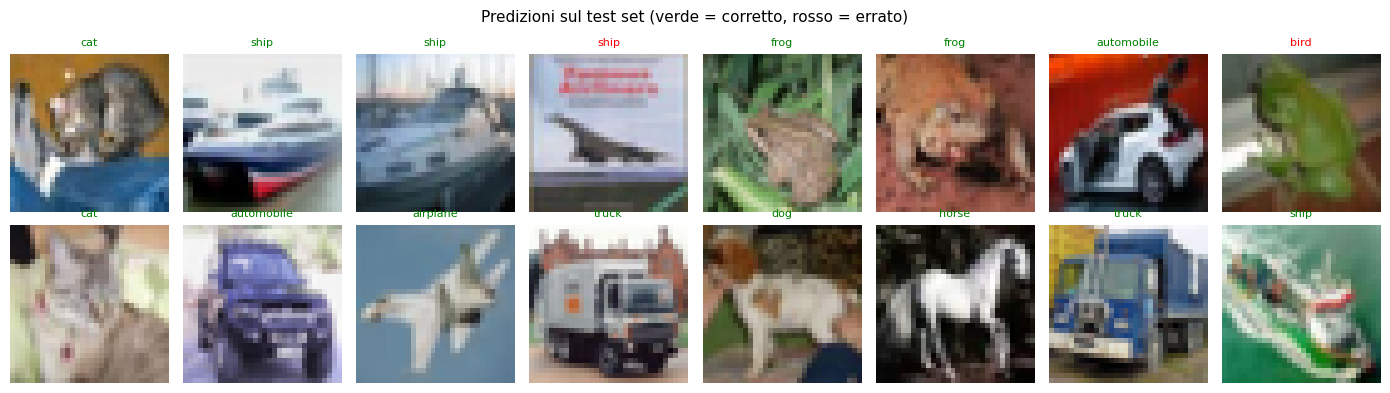

In [8]:
model.eval()
imgs, labels = next(iter(test_loader))
imgs_device = imgs.to(device)

with torch.no_grad():
    outputs = model(imgs_device)
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Predizioni sul test set (verde = corretto, rosso = errato)', fontsize=11)

for i, ax in enumerate(axes.flat):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    correct = preds[i] == labels[i]
    color = 'green' if correct else 'red'
    ax.imshow(img)
    ax.set_title(CLASSES[preds[i]], fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Salvataggio del Modello (opzionale)

In [9]:
# Salva solo i pesi (raccomandato)
torch.save(model.state_dict(), 'cnn_cifar10.pth')
print("Modello salvato in cnn_cifar10.pth")

# Per ricaricare:
# model = CNN().to(device)
# model.load_state_dict(torch.load('cnn_cifar10.pth'))
# model.eval()

Modello salvato in cnn_cifar10.pth


---

## Riepilogo

| Aspetto | MNIST | CIFAR-10 (questo notebook) |
|---|---|---|
| Canali input | 1 | **3 (RGB)** |
| Blocchi conv | 2 | **3** |
| Batch Norm | No | **Sì** |
| Data augmentation | No | **Sì** |
| LR scheduler | No | **Sì** |
| Accuracy attesa | ~99% | ~78–82% |

### Come migliorare ulteriormente
- Aumentare le epoch (es. 30–50)
- Usare architetture pre-addestrate: `torchvision.models.resnet18(pretrained=True)` (transfer learning)
- Aggiungere più data augmentation: `ColorJitter`, `RandomRotation`
- Usare `weight_decay` nell'ottimizzatore per regolarizzare